**Huntington's disease (HD)** is a genetic, progressive disorder that gradually affects the brain. It can cause problems with movement, thinking, and behavior/emotions.

What **causes** Huntington's disease?

HD is caused by a mutation in the HTT gene. The mutation is an expansion of a repeated DNA sequence called a CAG repeat.

Normally, the gene has a limited number of CAG repeats. In Huntington's disease, there are too many.

This causes production of an abnormal huntingtin protein, which eventually damages and kills neurons, particularly in certain areas of the brain.

**Why** does someone get it?

The important point is that HD is inherited.

If one parent has the disease-causing HTT mutation, each child has approximately a 50% chance of inheriting it.

It is autosomal dominant, meaning one altered copy of the gene is sufficient to cause the disease.

Main **symptoms**

HD generally affects three major areas:

1. Movement

Involuntary jerking/twisting movements (chorea)
Problems with coordination and balance
Difficulty walking
Slower or rigid movements in later stages
Difficulty speaking or swallowing

2. Cognitive function

Slower thinking
Difficulty concentrating
Problems with planning and organization
Difficulty making decisions
Memory problems
Progressive cognitive decline

3. Behavioral/psychiatric

Depression
Irritability
Anxiety
Changes in personality
Impulsivity
In some people, hallucinations or other psychiatric symptoms
Simple way to remember it

Think of Huntington's disease as affecting:

🧠 Thinking + 🚶 Movement +  Behavior

And because it is progressive, symptoms generally become more significant over time.

If you're studying a Huntington's disease dataset for ML, variables such as age, motor symptoms, cognitive decline, psychiatric symptoms, family history, etc. may be used as features to predict a diagnosis or disease severity.

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r'C:\Users\ASUS\OneDrive\Pictures\Desktop\Innomatics_workspace\Machine_Learning\Huntington-disease-stage-classification\data\Huntington_Disease_Dataset.csv')

In [3]:
df.head()

,Patient_ID,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,...,HTT_Gene_Expression_Level,Protein_Aggregation_Level,Random_Protein_Sequence,Random_Gene_Sequence,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,1.67,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.18,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,0.90,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.16,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,1.85,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier


In [4]:
df.columns = [col.lower().replace(' ','').replace('-','_').strip() for col in df.columns]

###Univariate Analysis

In [5]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
df.describe()

,age,htt_cag_repeat_length,chorea_score,brain_volume_loss,functional_capacity,htt_gene_expression_level,protein_aggregation_level
count,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000
mean,55.070566,57.516606,4.994399,5.261030,50.354829,1.301060,2.546519
std,14.762154,13.264153,2.897327,1.872995,29.189697,0.691657,1.414745
min,30.000000,35.000000,0.000000,2.000000,0.000000,0.100000,0.100000
25%,42.000000,46.000000,2.480000,3.640000,25.000000,0.700000,1.330000
50%,55.000000,58.000000,4.980000,5.280000,50.000000,1.300000,2.540000
75%,68.000000,69.000000,7.500000,6.880000,76.000000,1.900000,3.770000
max,80.000000,80.000000,10.000000,8.500000,100.000000,2.500000,5.000000


In [7]:
df['gene_mutation_type']

0              Deletion
1        Point Mutation
2           Duplication
3              Deletion
4             Insertion
              ...      
48531          Deletion
48532         Insertion
48533         Insertion
48534         Insertion
48535    Point Mutation
Name: gene_mutation_type, Length: 48536, dtype: object

In [8]:
df.columns

Index(['patient_id', 'age', 'sex', 'family_history', 'htt_cag_repeat_length',
       'motor_symptoms', 'cognitive_decline', 'chorea_score',
       'brain_volume_loss', 'functional_capacity', 'gene_mutation_type',
       'htt_gene_expression_level', 'protein_aggregation_level',
       'random_protein_sequence', 'random_gene_sequence', 'disease_stage',
       'gene/factor', 'chromosome_location', 'function', 'effect', 'category'],
      dtype='object')

Check dtypes

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48536 entries, 0 to 48535
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 48536 non-null  object 
 1   age                        48536 non-null  int64  
 2   sex                        48536 non-null  object 
 3   family_history             48536 non-null  object 
 4   htt_cag_repeat_length      48536 non-null  int64  
 5   motor_symptoms             48536 non-null  object 
 6   cognitive_decline          36417 non-null  object 
 7   chorea_score               48536 non-null  float64
 8   brain_volume_loss          48536 non-null  float64
 9   functional_capacity        48536 non-null  int64  
 10  gene_mutation_type         48536 non-null  object 
 11  htt_gene_expression_level  48536 non-null  float64
 12  protein_aggregation_level  48536 non-null  float64
 13  random_protein_sequence    48536 non-null  obj

In [10]:
df.shape

(48536, 21)

In [11]:
# is null
df.isna().sum()

patient_id                       0
age                              0
sex                              0
family_history                   0
htt_cag_repeat_length            0
motor_symptoms                   0
cognitive_decline            12119
chorea_score                     0
brain_volume_loss                0
functional_capacity              0
gene_mutation_type               0
htt_gene_expression_level        0
protein_aggregation_level        0
random_protein_sequence          0
random_gene_sequence             0
disease_stage                    0
gene/factor                      0
chromosome_location              0
function                         0
effect                           0
category                         0
dtype: int64

Cognitive decline in Huntington’s disease (HD) means a gradual worsening of a person's thinking and mental abilities over time. It is one of the major symptoms of HD, along with movement problems and psychiatric/behavioral changes.

In [12]:
df['cognitive_decline'].isna().sum()

np.int64(12119)

In [13]:
df['cognitive_decline'].isna().mean()* 100     # 24 percent null values

np.float64(24.96909510466458)

In [14]:
df['cognitive_decline'].value_counts()

cognitive_decline
Moderate    12243
Severe      12132
Mild        12042
Name: count, dtype: int64

In [15]:
df['cognitive_decline'].value_counts(normalize = True , dropna =False)*100  # normalize = True , converts the counts into percentages instead of raw counts.

cognitive_decline
Moderate    25.224576
Severe      24.995879
NaN         24.969095
Mild        24.810450
Name: proportion, dtype: float64

In [16]:
df['cognitive_decline'] = df['cognitive_decline'].fillna('Unknown')

In [17]:
df

,patient_id,age,sex,family_history,htt_cag_repeat_length,motor_symptoms,cognitive_decline,chorea_score,brain_volume_loss,functional_capacity,...,htt_gene_expression_level,protein_aggregation_level,random_protein_sequence,random_gene_sequence,disease_stage,gene/factor,chromosome_location,function,effect,category
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,1.67,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.18,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,0.90,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.16,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,1.85,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48531,27f82b73-b9fe-49d6-b6b9-82e667054725,78,Female,Yes,38,Moderate,Severe,0.09,4.71,89,...,0.49,1.24,WGYQYSFEMVIQWMYHSYMPQGGLGCHNENHYCFWQDHKVATAVTC...,CAATGACGCACCCTCGTAAGGGCTAGGCAGCGCCAGCCCACTTAAA...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
48532,ff5af7cc-8132-4791-8e8b-aac71f2bade1,61,Female,Yes,76,Mild,Unknown,8.80,6.92,78,...,2.44,3.34,TNVLFHILGLVENNMGQKFHQKAFPWCDTLMTSNWNGCAEGGNGEQ...,ACAAGAACAGTGGAACGGTTGAGTCACGGATGAGGCCTAGCGAGGT...,Middle,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier
48533,f594aab8-7acf-43cd-95d8-c197e202c4ea,66,Male,No,35,Severe,Severe,2.73,6.61,24,...,0.51,0.27,NRWNVDINSRMMHFYYFHTSPRSVTPWTPKQEREVYKQMFQKYAQS...,GGTATATCGTTAGGGCCGTCGGTGAACACTTCTAATCTAGGCTTAA...,Middle,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
48534,32052e20-c2ae-4314-95ce-5daf720b26ca,37,Female,Yes,80,Mild,Unknown,9.81,2.95,19,...,1.16,3.22,AKDHQGVPWLPRITQKQTVQQQPIKWMHWVPENARGTIIREFFAYA...,GGTTTTCGTTCTCGTAGTATCAACAGAGGGGAATTTTATTACTGGC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier


([<matplotlib.patches.Wedge at 0x1cdb19eecf0>,
 [Text(0.7723104537849985, 0.7832857479709495, 'Moderate'),
  Text(-0.788615837065662, 0.7668670429280589, 'Severe'),
  Text(-0.7677341655793268, -0.7877716997977363, 'Unknown'),
  Text(0.7824352321686106, -0.7731721072705952, 'Mild')],
 [Text(0.42126024751909, 0.4272467716205179, '25.22%'),
  Text(-0.43015409294490653, 0.4182911143243957, '25.00%'),
  Text(-0.41876409031599643, -0.42969365443512886, '24.97%'),
  Text(0.42678285391015114, -0.4217302403294155, '24.81%')])

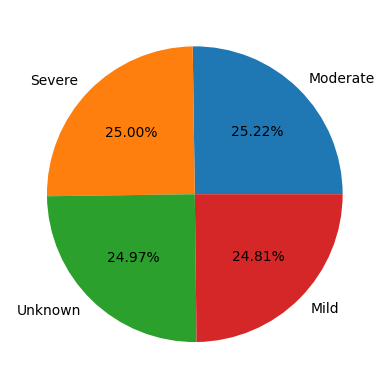

In [18]:
plt.pie(df['cognitive_decline'].value_counts(), labels = df['cognitive_decline'].value_counts().index,autopct = '%.2f%%')

In [19]:
df.isna().sum()

patient_id                   0
age                          0
sex                          0
family_history               0
htt_cag_repeat_length        0
motor_symptoms               0
cognitive_decline            0
chorea_score                 0
brain_volume_loss            0
functional_capacity          0
gene_mutation_type           0
htt_gene_expression_level    0
protein_aggregation_level    0
random_protein_sequence      0
random_gene_sequence         0
disease_stage                0
gene/factor                  0
chromosome_location          0
function                     0
effect                       0
category                     0
dtype: int64

Is Duplicate

In [20]:
df.duplicated().sum()  # No duplicate values

np.int64(0)

For Outliers

In [21]:
# for categorical values
cat_col = df.select_dtypes(include = ['object']).columns
for col in cat_col:
  print('Value counts:\n',df[col].value_counts())
  print('\nUnique values:\n',df[col].unique())

  print('\nNo. of unique values:',df[col].nunique())
  print('\n\n')

Value counts:
 patient_id
b063b8fb-9e12-40c2-b6bb-da675033dfd2    1
b2a49170-8561-4665-9371-2240b55dd87a    1
f5fae45d-8718-41c4-a957-6928f79f3c8e    1
66ab0567-050b-4d56-9ec4-b676309899a6    1
996a48e4-e841-418f-a539-5a7a86cd815d    1
                                       ..
9067a33a-127f-4bba-90e0-9011c6e5fcff    1
441c7e28-0a78-4e2b-856c-17375513e666    1
1bcd9c0e-1881-493f-8f95-2d5209aed381    1
d6041244-bc4a-4c5e-8f74-44ebc22bfa26    1
2a1348aa-5682-481d-8742-6e5996a3114e    1
Name: count, Length: 48536, dtype: int64

Unique values:
 ['b2a49170-8561-4665-9371-2240b55dd87a'
 'f5fae45d-8718-41c4-a957-6928f79f3c8e'
 '66ab0567-050b-4d56-9ec4-b676309899a6' ...
 'f594aab8-7acf-43cd-95d8-c197e202c4ea'
 '32052e20-c2ae-4314-95ce-5daf720b26ca'
 'b063b8fb-9e12-40c2-b6bb-da675033dfd2']

No. of unique values: 48536



Value counts:
 sex
Female    24270
Male      24266
Name: count, dtype: int64

Unique values:
 ['Male' 'Female']

No. of unique values: 2



Value counts:
 family_history
Yes    

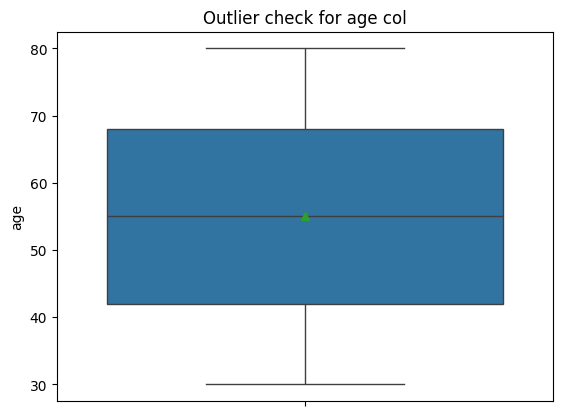

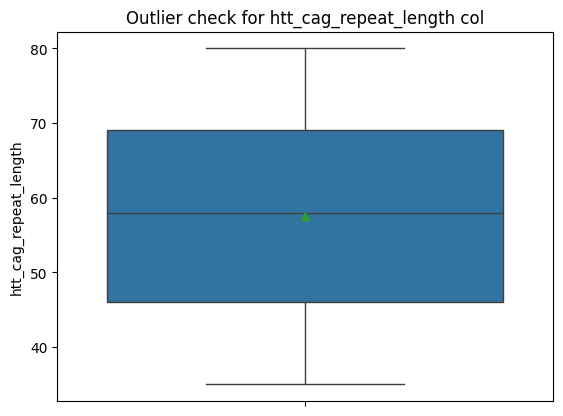

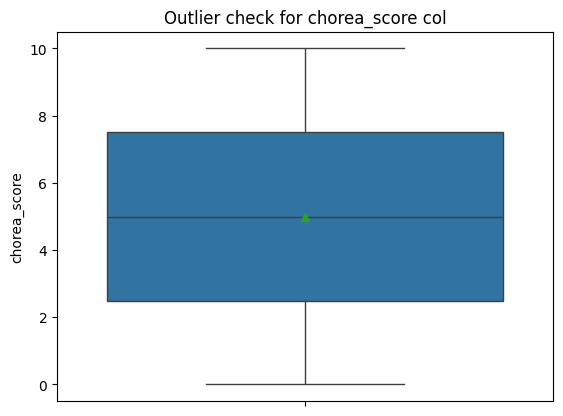

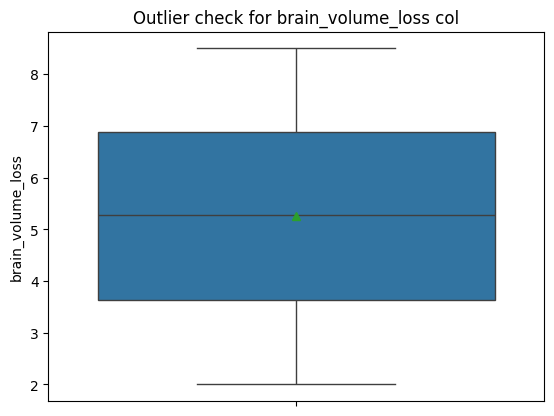

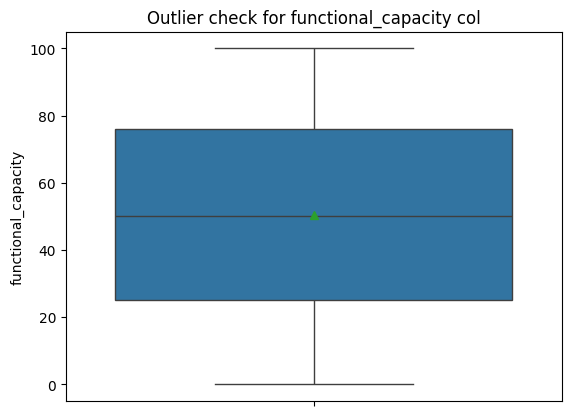

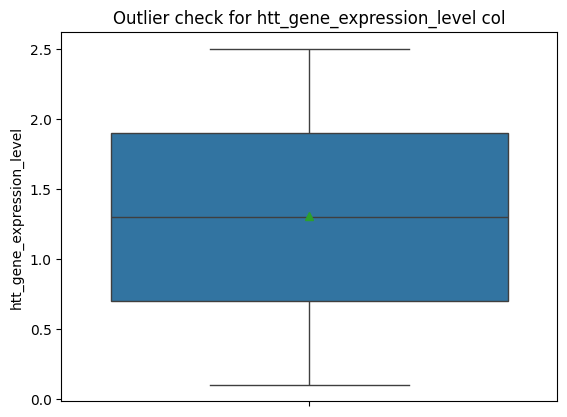

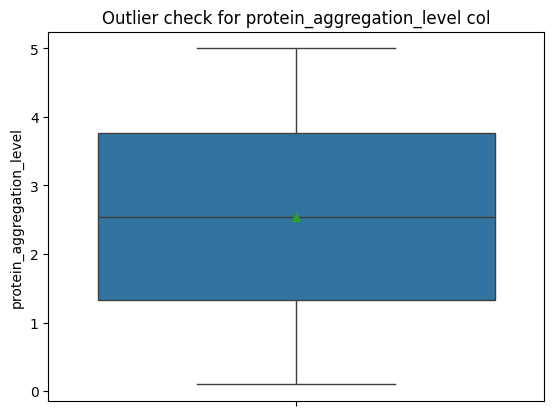

In [22]:
# for numerical col
num_col = df.select_dtypes(include = ['int64','float64']).columns

for col in num_col:
  sns.boxplot(df[col],showmeans = True)
  plt.title(f'Outlier check for {col} col')
  plt.show()

In [23]:
df.columns

Index(['patient_id', 'age', 'sex', 'family_history', 'htt_cag_repeat_length',
       'motor_symptoms', 'cognitive_decline', 'chorea_score',
       'brain_volume_loss', 'functional_capacity', 'gene_mutation_type',
       'htt_gene_expression_level', 'protein_aggregation_level',
       'random_protein_sequence', 'random_gene_sequence', 'disease_stage',
       'gene/factor', 'chromosome_location', 'function', 'effect', 'category'],
      dtype='object')

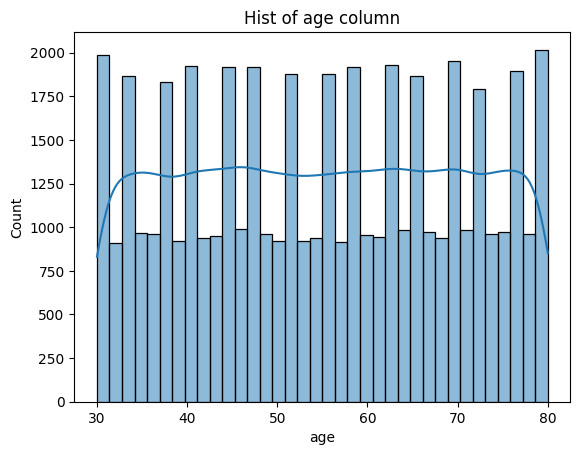

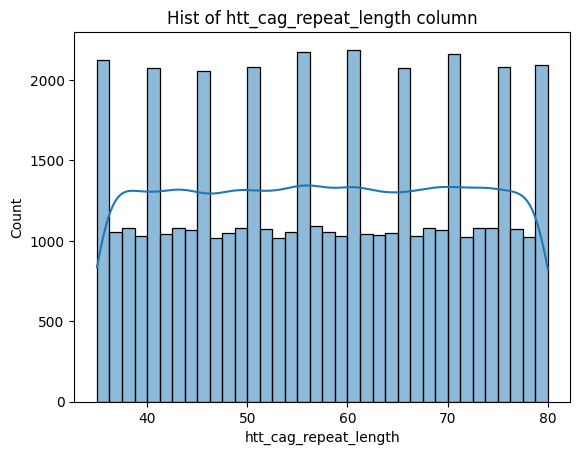

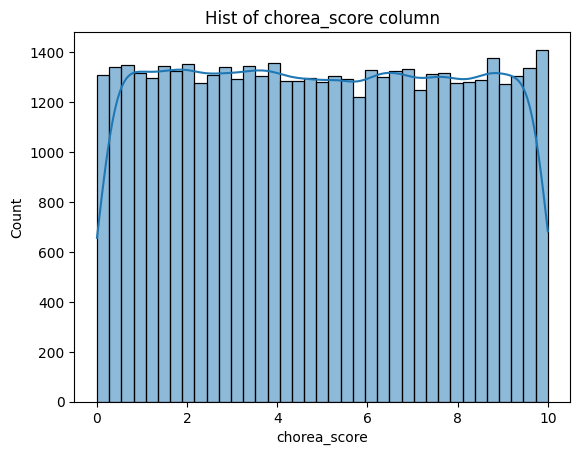

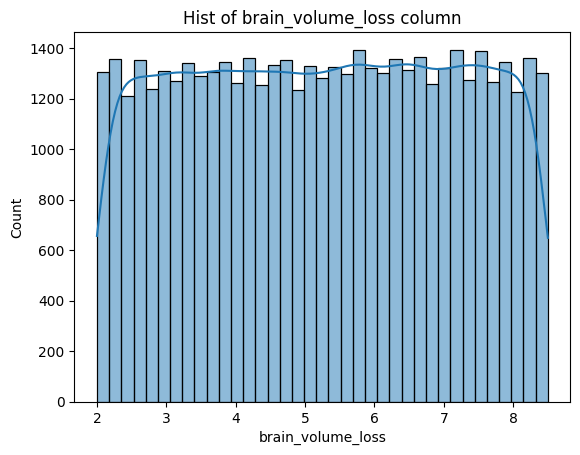

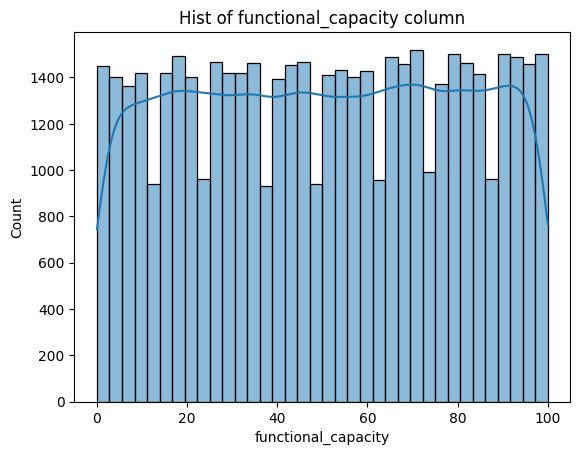

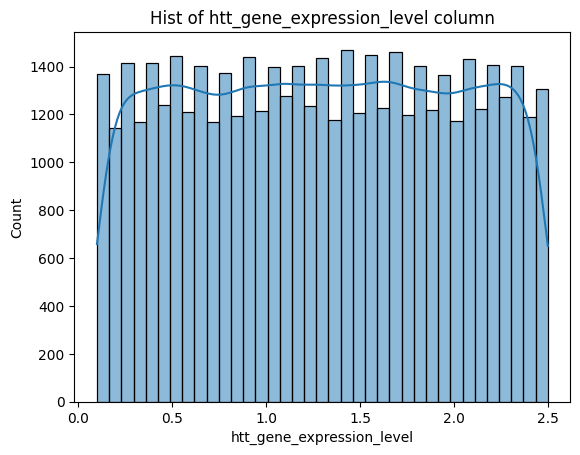

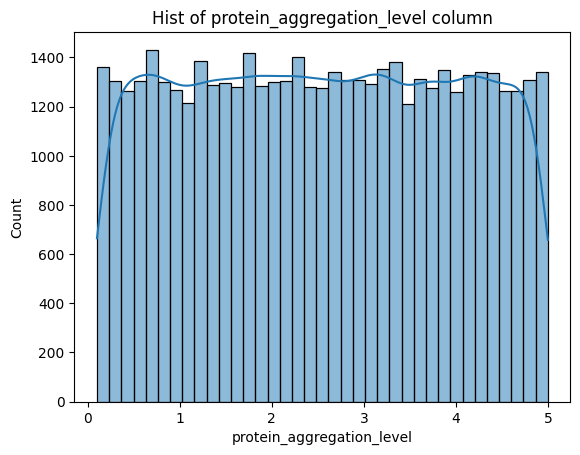

In [24]:
for col in num_col:
  sns.histplot(data = df, x = df[col]  , kde = True)
  plt.title(f'Hist of {col} column')
  plt.show()

###Bivariate Analysis

In [25]:
df

,patient_id,age,sex,family_history,htt_cag_repeat_length,motor_symptoms,cognitive_decline,chorea_score,brain_volume_loss,functional_capacity,...,htt_gene_expression_level,protein_aggregation_level,random_protein_sequence,random_gene_sequence,disease_stage,gene/factor,chromosome_location,function,effect,category
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,1.67,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.18,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,0.90,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.16,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,1.85,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48531,27f82b73-b9fe-49d6-b6b9-82e667054725,78,Female,Yes,38,Moderate,Severe,0.09,4.71,89,...,0.49,1.24,WGYQYSFEMVIQWMYHSYMPQGGLGCHNENHYCFWQDHKVATAVTC...,CAATGACGCACCCTCGTAAGGGCTAGGCAGCGCCAGCCCACTTAAA...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
48532,ff5af7cc-8132-4791-8e8b-aac71f2bade1,61,Female,Yes,76,Mild,Unknown,8.80,6.92,78,...,2.44,3.34,TNVLFHILGLVENNMGQKFHQKAFPWCDTLMTSNWNGCAEGGNGEQ...,ACAAGAACAGTGGAACGGTTGAGTCACGGATGAGGCCTAGCGAGGT...,Middle,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier
48533,f594aab8-7acf-43cd-95d8-c197e202c4ea,66,Male,No,35,Severe,Severe,2.73,6.61,24,...,0.51,0.27,NRWNVDINSRMMHFYYFHTSPRSVTPWTPKQEREVYKQMFQKYAQS...,GGTATATCGTTAGGGCCGTCGGTGAACACTTCTAATCTAGGCTTAA...,Middle,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
48534,32052e20-c2ae-4314-95ce-5daf720b26ca,37,Female,Yes,80,Mild,Unknown,9.81,2.95,19,...,1.16,3.22,AKDHQGVPWLPRITQKQTVQQQPIKWMHWVPENARGTIIREFFAYA...,GGTTTTCGTTCTCGTAGTATCAACAGAGGGGAATTTTATTACTGGC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier


In [26]:
df.columns

Index(['patient_id', 'age', 'sex', 'family_history', 'htt_cag_repeat_length',
       'motor_symptoms', 'cognitive_decline', 'chorea_score',
       'brain_volume_loss', 'functional_capacity', 'gene_mutation_type',
       'htt_gene_expression_level', 'protein_aggregation_level',
       'random_protein_sequence', 'random_gene_sequence', 'disease_stage',
       'gene/factor', 'chromosome_location', 'function', 'effect', 'category'],
      dtype='object')

In [27]:
# How does median Age vary across the 4 disease stages (Pre-Symptomatic to Late)?
df.groupby('disease_stage')['age'].median()


disease_stage
Early              55.0
Late               55.0
Middle             55.0
Pre-Symptomatic    55.0
Name: age, dtype: float64

In [28]:
# Does HTT_CAG_Repeat_Length show a progressive increase across disease stages?
df.groupby('disease_stage')['htt_cag_repeat_length'].median()


disease_stage
Early              58.0
Late               58.0
Middle             58.0
Pre-Symptomatic    57.0
Name: htt_cag_repeat_length, dtype: float64

In [29]:
df['disease_stage'].unique()

array(['Middle', 'Pre-Symptomatic', 'Early', 'Late'], dtype=object)

In [30]:
# Is there a monotonic increase in Brain_Volume_Loss from Pre-Symptomatic to Late stages?
stage_order = ['Pre-Symptomatic' , 'Early' , 'Middle', 'Late']
df.groupby('disease_stage')['brain_volume_loss'].median().reindex(stage_order)
# Yes , it is monotonic. cause when the diesease stage increase the brain volume loss is also increase.



disease_stage
Pre-Symptomatic    5.26
Early              5.26
Middle             5.27
Late               5.31
Name: brain_volume_loss, dtype: float64

In [31]:
# Does Functional_Capacity decrease progressively across the disease stages?
df.groupby('disease_stage')['functional_capacity'].median().reindex(stage_order)
# Ans :- at first it decrease slightly then increased.


disease_stage
Pre-Symptomatic    51.0
Early              50.0
Middle             50.0
Late               51.0
Name: functional_capacity, dtype: float64

In [32]:
# How does Chorea_Score differ between Pre-Symptomatic patients and symptomatic stages (Early, Middle, Late)?
df.groupby('disease_stage')['chorea_score'].median().reindex(stage_order)

disease_stage
Pre-Symptomatic    4.95
Early              5.04
Middle             4.92
Late               5.01
Name: chorea_score, dtype: float64

In [33]:
# Does Protein_Aggregation_Level increase with disease severity?
df.groupby('disease_stage')['protein_aggregation_level'].median().reindex(stage_order)
# No

disease_stage
Pre-Symptomatic    2.53
Early              2.51
Middle             2.59
Late               2.54
Name: protein_aggregation_level, dtype: float64

In [34]:
# Is HTT_Gene_Expression_Level elevated in later stages compared to early/pre-symptomatic stages?
df.groupby('disease_stage')['htt_cag_repeat_length'].median().reindex(stage_order)


disease_stage
Pre-Symptomatic    57.0
Early              58.0
Middle             58.0
Late               58.0
Name: htt_cag_repeat_length, dtype: float64

In [35]:
# How do the proportions of Motor_Symptoms levels shift across Disease_Stage?
pd.crosstab(df['disease_stage'], df['motor_symptoms'] , normalize = 'index') * 100

motor_symptoms,Mild,Moderate,Severe
disease_stage,,,
Early,33.236370,33.992686,32.770944
Late,33.083832,32.884232,34.031936
Middle,33.045813,33.818862,33.135324
Pre-Symptomatic,33.467312,33.311459,33.221229


In [36]:
df['cognitive_decline'].unique()

array(['Severe', 'Moderate', 'Mild', 'Unknown'], dtype=object)

In [37]:
# How does Cognitive_Decline severity align with each Disease_Stage?
pd.crosstab(df['disease_stage'],df['cognitive_decline'], normalize = 'index')*100


cognitive_decline,Mild,Moderate,Severe,Unknown
disease_stage,,,,
Early,24.534574,25.307513,25.623338,24.534574
Late,24.708916,25.415835,24.908516,24.966733
Middle,25.412971,24.721295,25.071202,24.794532
Pre-Symptomatic,24.575507,25.461406,24.386843,25.576245


In [38]:
df['family_history'].unique()

array(['No', 'Yes'], dtype=object)

In [39]:
# Is Family_History equally distributed across all disease stages?
pd.crosstab(df['disease_stage'], df['family_history'], normalize = 'index')*100

family_history,No,Yes
disease_stage,,
Early,48.944481,51.055519
Late,49.675649,50.324351
Middle,49.963382,50.036618
Pre-Symptomatic,50.898204,49.101796


In [40]:
df['gene_mutation_type'].unique()

array(['Deletion', 'Point Mutation', 'Duplication', 'Insertion'],
      dtype=object)

In [41]:
# Does any specific Gene_Mutation_Type occur disproportionately in the Late or Pre-Symptomatic stage?
pd.crosstab(df['disease_stage'], df['gene_mutation_type'],normalize = 'index')*100

gene_mutation_type,Deletion,Duplication,Insertion,Point Mutation
disease_stage,,,,
Early,24.143949,24.916888,25.282580,25.656582
Late,24.176647,25.382568,25.507319,24.933466
Middle,24.770120,25.339735,25.290911,24.599235
Pre-Symptomatic,25.330162,25.067673,24.788779,24.813387


In [42]:
df.columns

Index(['patient_id', 'age', 'sex', 'family_history', 'htt_cag_repeat_length',
       'motor_symptoms', 'cognitive_decline', 'chorea_score',
       'brain_volume_loss', 'functional_capacity', 'gene_mutation_type',
       'htt_gene_expression_level', 'protein_aggregation_level',
       'random_protein_sequence', 'random_gene_sequence', 'disease_stage',
       'gene/factor', 'chromosome_location', 'function', 'effect', 'category'],
      dtype='object')

In [43]:
# sex | chromosome_region
pd.crosstab(df['sex'], df['chromosome_location'] ,normalize = 'index')*100  # Percentages

chromosome_location,3p22.2,4p16.3,5q14.1
sex,,,
Female,25.121549,49.929955,24.948496
Male,25.245199,50.024726,24.730075


In [44]:
# sex | category
pd.crosstab(df['sex'], df['category'],normalize = 'index')*100

category,Cis-acting Modifier,Primary Cause,Trans-acting Modifier
sex,,,
Female,24.717759,25.212196,50.070045
Male,24.845463,25.179263,49.975274


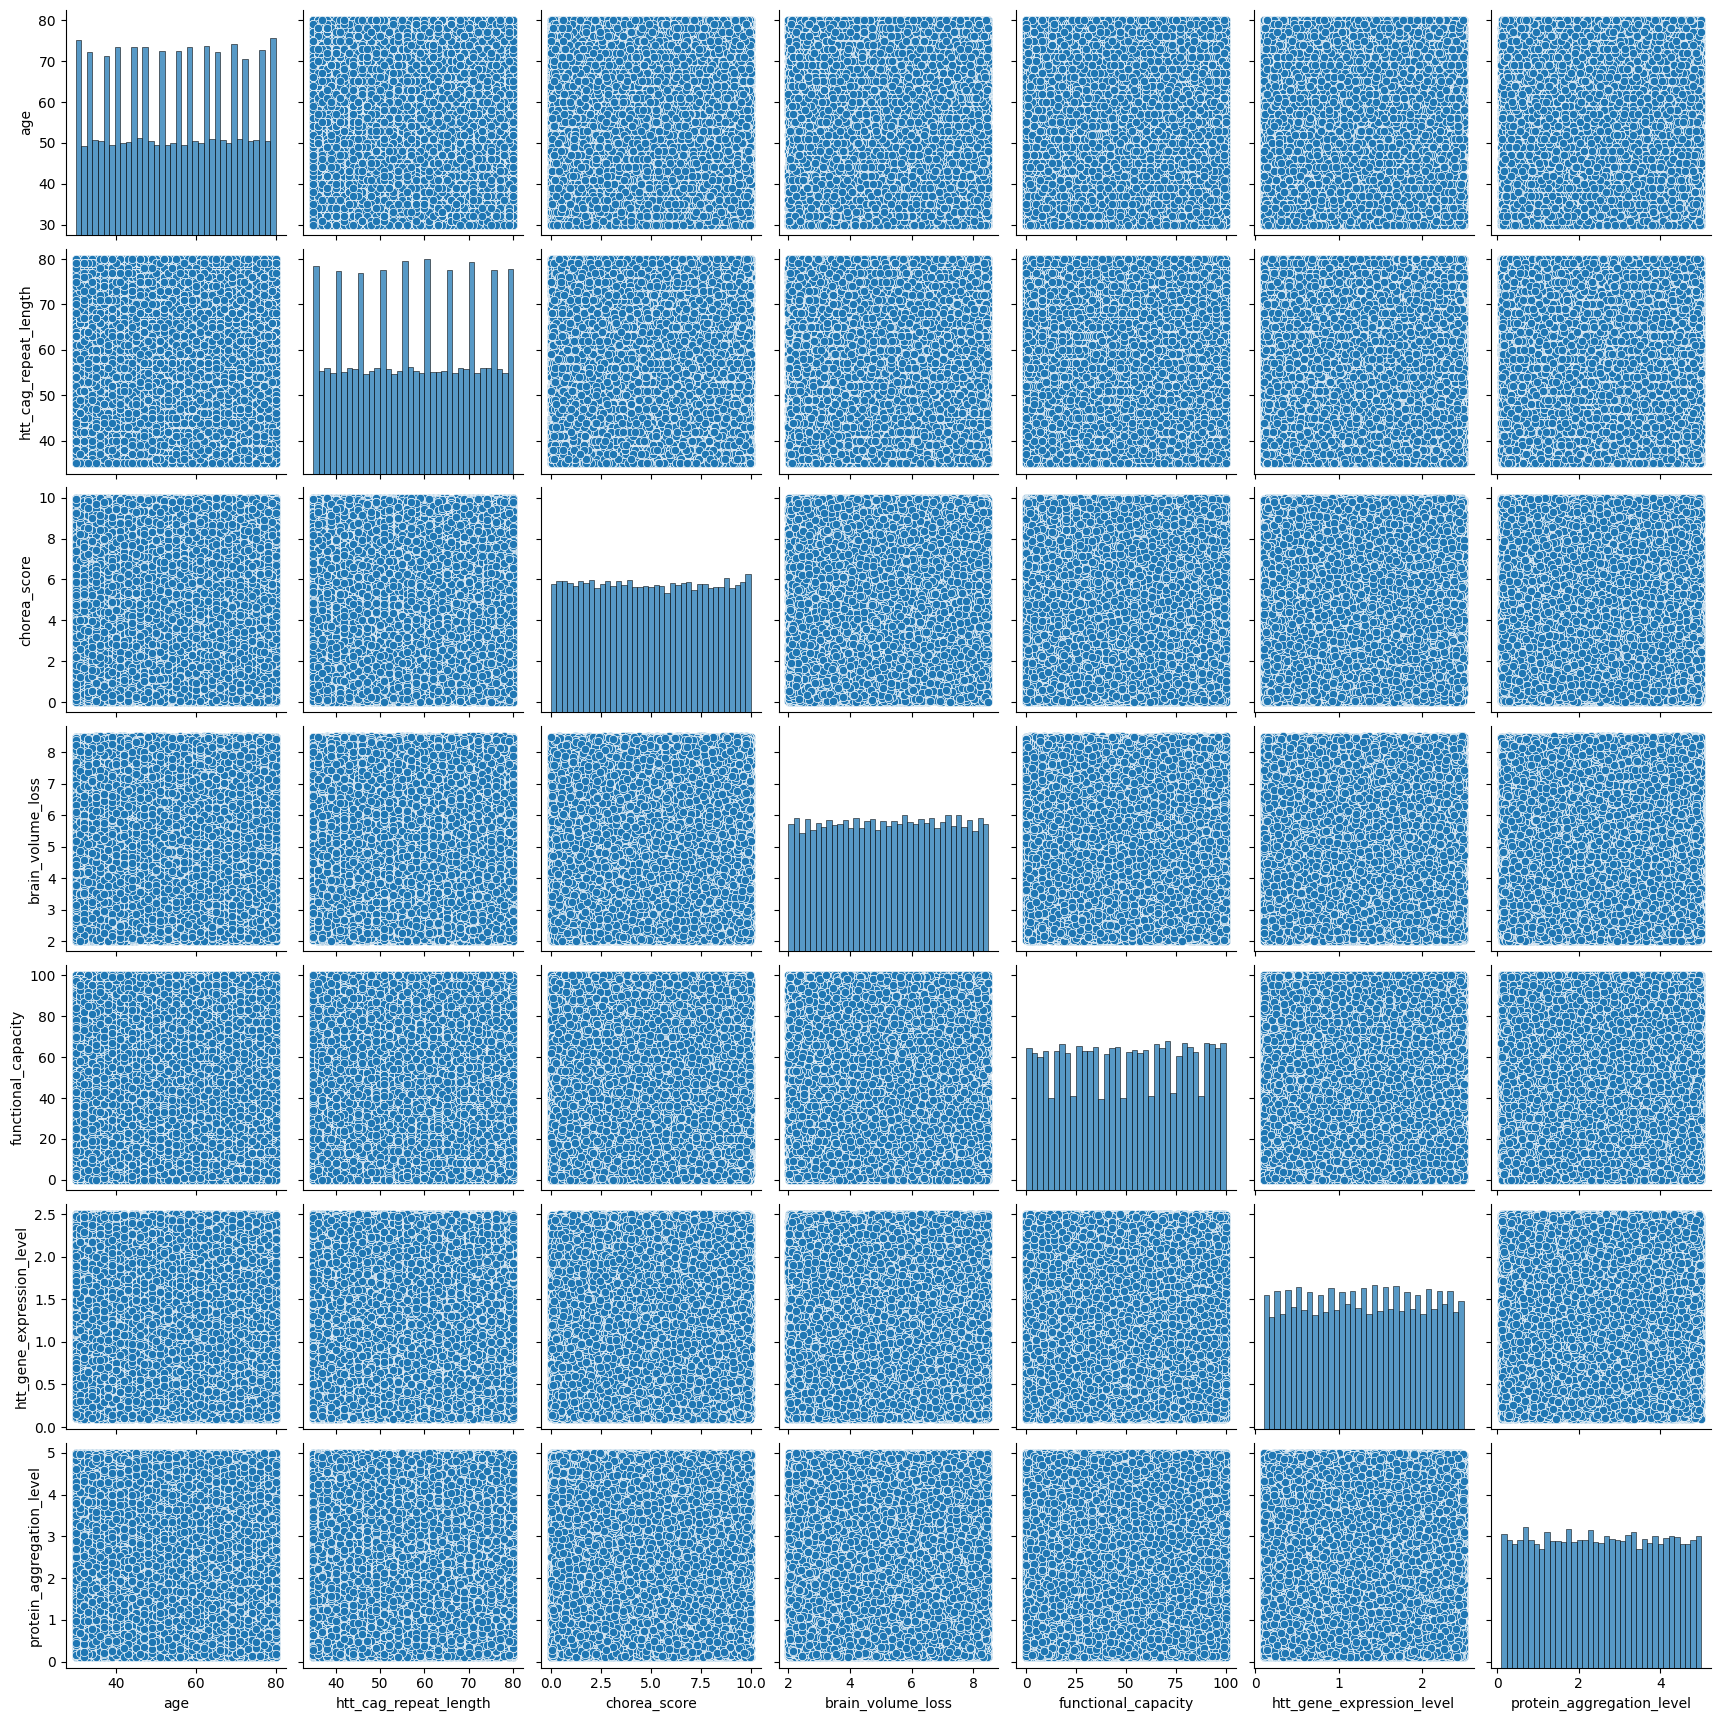

In [45]:
sns.pairplot(df[num_col])
plt.show()

In [46]:
df.columns

Index(['patient_id', 'age', 'sex', 'family_history', 'htt_cag_repeat_length',
       'motor_symptoms', 'cognitive_decline', 'chorea_score',
       'brain_volume_loss', 'functional_capacity', 'gene_mutation_type',
       'htt_gene_expression_level', 'protein_aggregation_level',
       'random_protein_sequence', 'random_gene_sequence', 'disease_stage',
       'gene/factor', 'chromosome_location', 'function', 'effect', 'category'],
      dtype='object')

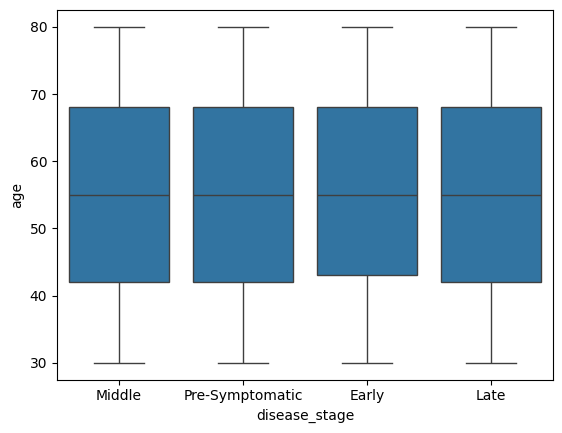

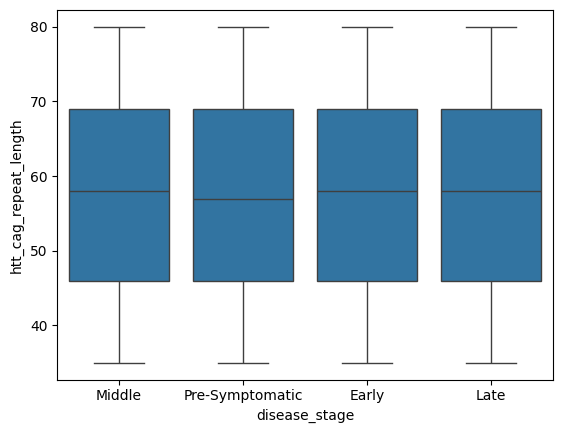

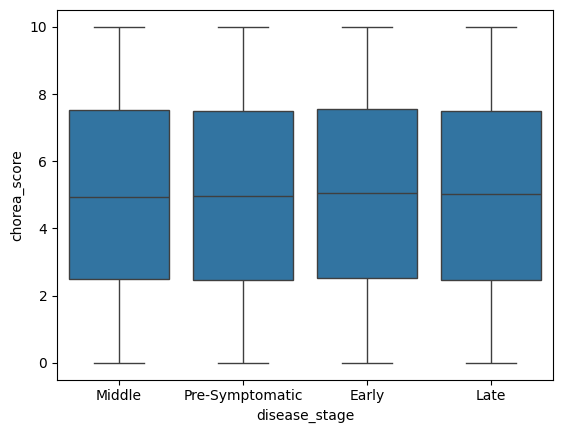

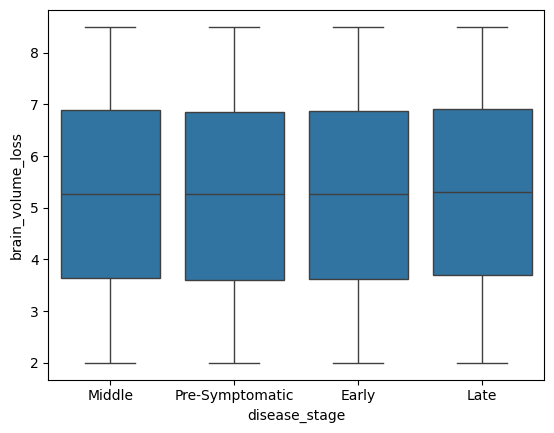

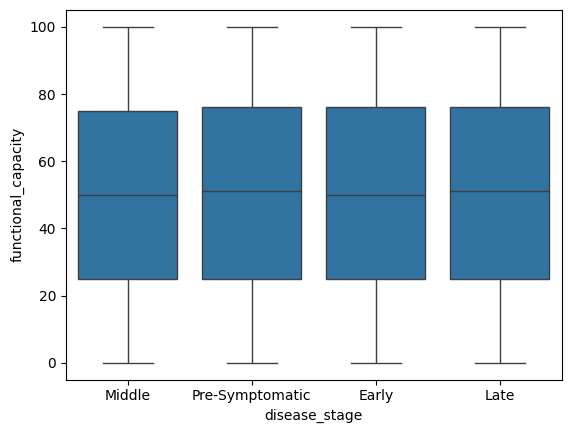

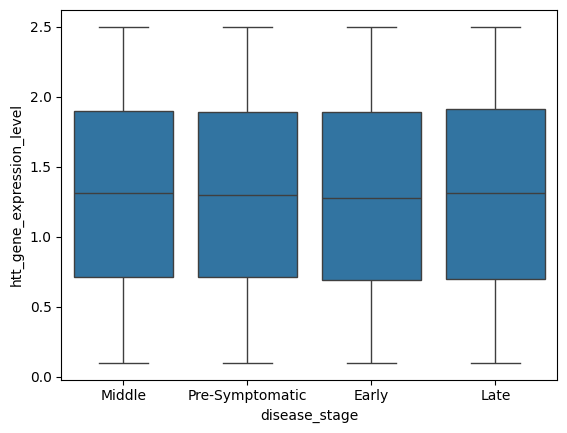

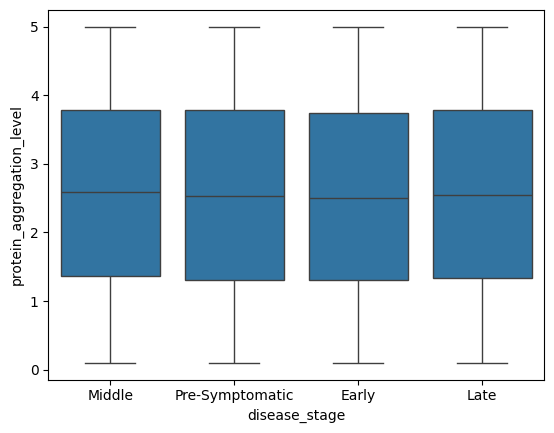

In [47]:
for i in num_col:
  sns.boxplot(
      data=df,
      x='disease_stage',
      y=i
  )

  plt.show()

In [48]:
num_col

Index(['age', 'htt_cag_repeat_length', 'chorea_score', 'brain_volume_loss',
       'functional_capacity', 'htt_gene_expression_level',
       'protein_aggregation_level'],
      dtype='object')

In [49]:
# Statistical Summary of Numerical Features by Disease Stage (target col)
df.groupby('disease_stage')[['age', 'htt_cag_repeat_length', 'chorea_score', 'brain_volume_loss',
       'functional_capacity', 'htt_gene_expression_level',
       'protein_aggregation_level' ]].agg([
           'mean' , 'median' , 'std' , 'var'
       ])

age                                \
                      mean median        std         var   
disease_stage                                              
Early            55.211686   55.0  14.728964  216.942385   
Late             55.125333   55.0  14.799742  219.032365   
Middle           55.067459   55.0  14.769185  218.128831   
Pre-Symptomatic  54.880404   55.0  14.750486  217.576836   

                htt_cag_repeat_length                                \
                                 mean median        std         var   
disease_stage                                                         
Early                       57.555352   58.0  13.276542  176.266573   
Late                        57.729624   58.0  13.224389  174.884472   
Middle                      57.528440   58.0  13.301695  176.935084   
Pre-Symptomatic             57.256337   57.0  13.250505  175.575878   

                chorea_score         ... functional_capacity              \
                        mean median  ...                 std         var   
disease_stage                        ...                                   
Early               5.025014   5.04  ...           29.212085  853.345915   
Late                4.995626   5.01  ...           29.220127  853.815840   
Middle              4.982510   4.92  ...           29.162259  850.437347   
Pre-Symptomatic     4.974958   4.95  ...           29.164777  850.584221   

                htt_gene_expression_level                             \
                                     mean median       std       var   
disease_stage                                                          
Early                            1.295910   1.28  0.691687  0.478431   
Late                             1.305248   1.31  0.694946  0.482950   
Middle                           1.302867   1.31  0.690422  0.476682   
Pre-Symptomatic                  1.300192   1.30  0.689666  0.475640   

                protein_aggregation_level                             
                                     mean median       std       var  
disease_stage                                                         
Early                            2.519875   2.51  1.412272  1.994511  
Late                             2.548996   2.54  1.417379  2.008964  
Middle                           2.572170   2.59  1.409631  1.987060  
Pre-Symptomatic                  2.544516   2.53  1.419410  2.014723  

[4 rows x 28 columns]

In [50]:
# percentage distribution of each category within each disease stage.
cat_cols = [
    'sex',
    'family_history',
    'motor_symptoms',
    'cognitive_decline',
    'gene_mutation_type',
    'gene/factor',
    'function',
    'effect',
    'category'
]

for col in cat_cols:
    print(f"\n{col}")
    print(
        df.groupby('disease_stage')[col]
          .value_counts(normalize=True)
          .mul(100)
    )


sex
disease_stage    sex   
Early            Female    50.548537
                 Male      49.451463
Late             Male      50.149701
                 Female    49.850299
Middle           Male      50.337700
                 Female    49.662300
Pre-Symptomatic  Male      50.036912
                 Female    49.963088
Name: proportion, dtype: float64

family_history
disease_stage    family_history
Early            Yes               51.055519
                 No                48.944481
Late             Yes               50.324351
                 No                49.675649
Middle           Yes               50.036618
                 No                49.963382
Pre-Symptomatic  No                50.898204
                 Yes               49.101796
Name: proportion, dtype: float64

motor_symptoms
disease_stage    motor_symptoms
Early            Moderate          33.992686
                 Mild              33.236370
                 Severe            32.770944
Late             S

In [51]:
# Age at Assessment vs. CAG Repeats: What is the correlation between Age and HTT_CAG_Repeat_Length within each individual Disease_Stage?
df.groupby('disease_stage')[['age','htt_cag_repeat_length']].corr()

age  htt_cag_repeat_length
disease_stage                                                         
Early           age                    1.000000               0.004352
                htt_cag_repeat_length  0.004352               1.000000
Late            age                    1.000000              -0.000311
                htt_cag_repeat_length -0.000311               1.000000
Middle          age                    1.000000               0.002546
                htt_cag_repeat_length  0.002546               1.000000
Pre-Symptomatic age                    1.000000               0.001270
                htt_cag_repeat_length  0.001270               1.000000

In [52]:
#Do patients diagnosed in Middle or Late stages at younger ages possess significantly longer CAG repeats?
middle_late = df[df['disease_stage'].isin(['Middle', 'Late'])]
middle_late[['age', 'htt_cag_repeat_length', 'disease_stage']].describe()

middle_late.groupby('disease_stage').apply(
    lambda x: x['age'].corr(x['htt_cag_repeat_length'])
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7780\2048080937.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  middle_late.groupby('disease_stage').apply(


disease_stage
Late     -0.000311
Middle    0.002546
dtype: float64

In [53]:
# Does Sex have any statistically significant association with HTT_CAG_Repeat_Length, Chorea_Score, or Brain_Volume_Loss?
df.groupby('sex')[[
    'htt_cag_repeat_length',
    'chorea_score',
    'brain_volume_loss'
]].mean()


,htt_cag_repeat_length,chorea_score,brain_volume_loss
sex,,,
Female,57.470004,4.989863,5.262415
Male,57.563216,4.998936,5.259644


In [54]:
# Is there a difference in disease severity or stage between male and female patients?
pd.crosstab(df['sex'], df['disease_stage'] , normalize = 'index')*100

disease_stage,Early,Late,Middle,Pre-Symptomatic
sex,,,,
Female,25.059745,24.697157,25.146271,25.096827
Male,24.519904,24.849584,25.492459,25.138053


<Axes: xlabel='gene_mutation_type', ylabel='count'>

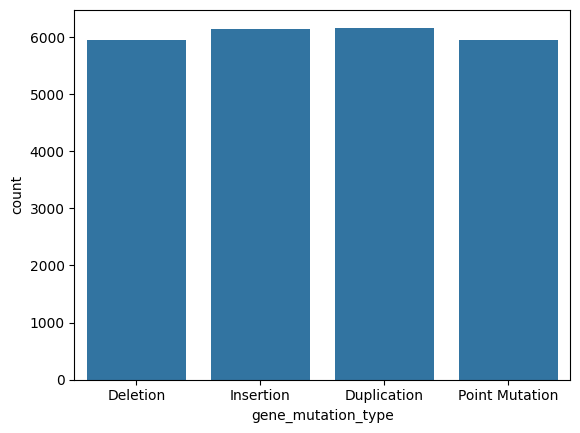

In [55]:
# For patients with Family_History == 'No', is there a difference in the distribution of Gene_Mutation_Type
no_family_history = df[df['family_history'] == 'No']
sns.countplot(data = no_family_history , x = 'gene_mutation_type')


In [56]:
# Are patients with negative family history diagnosed at older ages compared to those with positive family history?
df.groupby('family_history')['age'].agg(['mean' , 'median' , 'std' , 'count'])


,mean,median,std,count
family_history,,,,
No,54.989094,55.0,14.741440,24207
Yes,55.151630,55.0,14.782593,24329


In [57]:
df.columns

Index(['patient_id', 'age', 'sex', 'family_history', 'htt_cag_repeat_length',
       'motor_symptoms', 'cognitive_decline', 'chorea_score',
       'brain_volume_loss', 'functional_capacity', 'gene_mutation_type',
       'htt_gene_expression_level', 'protein_aggregation_level',
       'random_protein_sequence', 'random_gene_sequence', 'disease_stage',
       'gene/factor', 'chromosome_location', 'function', 'effect', 'category'],
      dtype='object')

In [58]:
# In patients with juvenile-range CAG repeats greater than 60 , what are the typical values for Age, Motor_Symptoms, and Chorea_Score?
juvenile_cag = df[df['htt_cag_repeat_length'] > 60]
df[['age','motor_symptoms','chorea_score']].describe()

,age,chorea_score
count,48536.000000,48536.000000
mean,55.070566,4.994399
std,14.762154,2.897327
min,30.000000,0.000000
25%,42.000000,2.480000
50%,55.000000,4.980000
75%,68.000000,7.500000
max,80.000000,10.000000


In [59]:

pd.crosstab(df['sex'] , df['category'])

category,Cis-acting Modifier,Primary Cause,Trans-acting Modifier
sex,,,
Female,5999,6119,12152
Male,6029,6110,12127


In [60]:

pd.crosstab(df['sex'], df['effect'])

effect,CAG Repeat Expansion,Faster Disease Onset,Neurodegeneration
sex,,,
Female,12152,5999,6119
Male,12127,6029,6110


In [61]:
# sex | effect
pd.crosstab(df['sex'], df['effect'], normalize = 'index')*100

effect,CAG Repeat Expansion,Faster Disease Onset,Neurodegeneration
sex,,,
Female,50.070045,24.717759,25.212196
Male,49.975274,24.845463,25.179263


In [62]:
# sex | functions percentage
pd.crosstab(df['sex'], df['function'])

function,CAG Repeat Instability,CAG Trinucleotide Repeat Expansion,Mismatch Repair
sex,,,
Female,5999,6119,12152
Male,6029,6110,12127


In [63]:
pd.crosstab(df['sex'], df['function'], normalize = 'index')*100

function,CAG Repeat Instability,CAG Trinucleotide Repeat Expansion,Mismatch Repair
sex,,,
Female,24.717759,25.212196,50.070045
Male,24.845463,25.179263,49.975274


In [64]:
# sex | gene factor percentage

pd.crosstab(df['sex'] , df['gene/factor'] , normalize = 'index') * 100

gene/factor,HTT,HTT (Somatic Expansion),MLH1,MSH3
sex,,,,
Female,25.212196,24.717759,25.121549,24.948496
Male,25.179263,24.845463,25.245199,24.730075


In [65]:
# sex | gene factor
pd.crosstab(df['sex'] , df['gene/factor'])

gene/factor,HTT,HTT (Somatic Expansion),MLH1,MSH3
sex,,,,
Female,6119,5999,6097,6055
Male,6110,6029,6126,6001


In [66]:
# sex | Gene mutation type

pd.crosstab(df['sex'] ,df['gene_mutation_type'] )

gene_mutation_type,Deletion,Duplication,Insertion,Point Mutation
sex,,,,
Female,5888,6137,6159,6086
Male,6056,6083,6080,6047


In [67]:
# sex | gene mutation type percentage

pd.crosstab(df['sex'] , df['gene_mutation_type'] , normalize = 'index')*100

gene_mutation_type,Deletion,Duplication,Insertion,Point Mutation
sex,,,,
Female,24.260404,25.286362,25.377009,25.076226
Male,24.956730,25.067996,25.055633,24.919641


In [68]:
# class cgnitive decline for sex

pd.crosstab(df['sex'] , df['cognitive_decline'])

cognitive_decline,Mild,Moderate,Severe,Unknown
sex,,,,
Female,6120,6091,6006,6053
Male,5922,6152,6126,6066


In [69]:
df['age'].unique().max()

np.int64(80)

In [70]:
def age_group(age_col):
  if age_col < 50:
    return 'Adult'
  elif age_col > 50:
    return 'old'
df['age_cat'] = df['age'].apply(age_group)


In [71]:
df

,patient_id,age,sex,family_history,htt_cag_repeat_length,motor_symptoms,cognitive_decline,chorea_score,brain_volume_loss,functional_capacity,...,protein_aggregation_level,random_protein_sequence,random_gene_sequence,disease_stage,gene/factor,chromosome_location,function,effect,category,age_cat
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause,Adult
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause,Adult
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48531,27f82b73-b9fe-49d6-b6b9-82e667054725,78,Female,Yes,38,Moderate,Severe,0.09,4.71,89,...,1.24,WGYQYSFEMVIQWMYHSYMPQGGLGCHNENHYCFWQDHKVATAVTC...,CAATGACGCACCCTCGTAAGGGCTAGGCAGCGCCAGCCCACTTAAA...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
48532,ff5af7cc-8132-4791-8e8b-aac71f2bade1,61,Female,Yes,76,Mild,Unknown,8.80,6.92,78,...,3.34,TNVLFHILGLVENNMGQKFHQKAFPWCDTLMTSNWNGCAEGGNGEQ...,ACAAGAACAGTGGAACGGTTGAGTCACGGATGAGGCCTAGCGAGGT...,Middle,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,old
48533,f594aab8-7acf-43cd-95d8-c197e202c4ea,66,Male,No,35,Severe,Severe,2.73,6.61,24,...,0.27,NRWNVDINSRMMHFYYFHTSPRSVTPWTPKQEREVYKQMFQKYAQS...,GGTATATCGTTAGGGCCGTCGGTGAACACTTCTAATCTAGGCTTAA...,Middle,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
48534,32052e20-c2ae-4314-95ce-5daf720b26ca,37,Female,Yes,80,Mild,Unknown,9.81,2.95,19,...,3.22,AKDHQGVPWLPRITQKQTVQQQPIKWMHWVPENARGTIIREFFAYA...,GGTTTTCGTTCTCGTAGTATCAACAGAGGGGAATTTTATTACTGGC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,Adult


<Axes: >

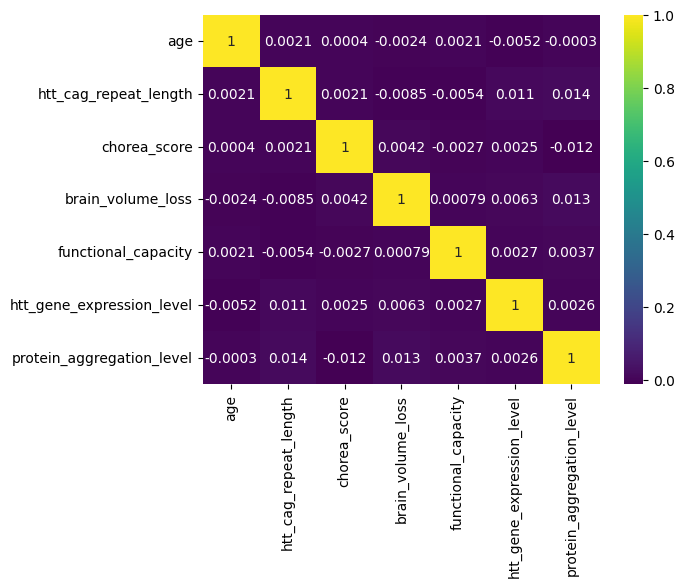

In [72]:
# heat map

sns.heatmap(data = df[num_col].corr() , annot = True , cmap = 'viridis' )

In [73]:
df[num_col].corr()

,age,htt_cag_repeat_length,chorea_score,brain_volume_loss,functional_capacity,htt_gene_expression_level,protein_aggregation_level
age,1.000000,0.002051,0.000405,-0.002439,0.002096,-0.005172,-0.000304
htt_cag_repeat_length,0.002051,1.000000,0.002078,-0.008470,-0.005382,0.011170,0.014360
chorea_score,0.000405,0.002078,1.000000,0.004227,-0.002651,0.002485,-0.012492
brain_volume_loss,-0.002439,-0.008470,0.004227,1.000000,0.000790,0.006296,0.012553
functional_capacity,0.002096,-0.005382,-0.002651,0.000790,1.000000,0.002689,0.003715
htt_gene_expression_level,-0.005172,0.011170,0.002485,0.006296,0.002689,1.000000,0.002638
protein_aggregation_level,-0.000304,0.014360,-0.012492,0.012553,0.003715,0.002638,1.000000


In [74]:
df.select_dtypes(include = ['number'])

,age,htt_cag_repeat_length,chorea_score,brain_volume_loss,functional_capacity,htt_gene_expression_level,protein_aggregation_level
0,31,67,8.80,3.20,94,1.67,0.58
1,33,38,3.24,5.98,50,0.18,0.30
2,69,37,1.01,2.82,69,0.90,1.04
3,66,50,3.21,6.77,76,1.16,1.87
4,43,48,2.31,7.53,70,1.85,2.94
...,...,...,...,...,...,...,...
48531,78,38,0.09,4.71,89,0.49,1.24
48532,61,76,8.80,6.92,78,2.44,3.34
48533,66,35,2.73,6.61,24,0.51,0.27
48534,37,80,9.81,2.95,19,1.16,3.22


In [75]:
pd.pivot_table(data = df , values = ['htt_cag_repeat_length','chorea_score','brain_volume_loss','functional_capacity','protein_aggregation_level'] , index = 'sex' , aggfunc = 'mean')

,brain_volume_loss,chorea_score,functional_capacity,htt_cag_repeat_length,protein_aggregation_level
sex,,,,,
Female,5.262415,4.989863,50.542233,57.470004,2.544042
Male,5.259644,4.998936,50.167395,57.563216,2.548997


In [76]:
# find the all numerical corr with sex
pd.pivot_table(data = df , values = ['htt_cag_repeat_length','chorea_score','brain_volume_loss','functional_capacity','protein_aggregation_level'] , index = 'sex' , aggfunc = 'corr')


brain_volume_loss  chorea_score  \
sex                                                                 
Female htt_cag_repeat_length              -0.009903      0.008091   
       chorea_score                        0.004368      1.000000   
       brain_volume_loss                   1.000000      0.004368   
       functional_capacity                 0.003379     -0.008446   
       protein_aggregation_level           0.010430     -0.013794   
Male   htt_cag_repeat_length              -0.007043     -0.003996   
       chorea_score                        0.004089      1.000000   
       brain_volume_loss                   1.000000      0.004089   
       functional_capacity                -0.001783      0.003205   
       protein_aggregation_level           0.014651     -0.011191   

                                  functional_capacity  htt_cag_repeat_length  \
sex                                                                            
Female htt_cag_repeat_length                -0.013781               1.000000   
       chorea_score                         -0.008446               0.008091   
       brain_volume_loss                     0.003379              -0.009903   
       functional_capacity                   1.000000              -0.013781   
       protein_aggregation_level             0.008668               0.017023   
Male   htt_cag_repeat_length                 0.003046               1.000000   
       chorea_score                          0.003205              -0.003996   
       brain_volume_loss                    -0.001783              -0.007043   
       functional_capacity                   1.000000               0.003046   
       protein_aggregation_level            -0.001185               0.011698   

                                  protein_aggregation_level  
sex                                                          
Female htt_cag_repeat_length                       0.017023  
       chorea_score                               -0.013794  
       brain_volume_loss                           0.010430  
       functional_capacity                         0.008668  
       protein_aggregation_level                   1.000000  
Male   htt_cag_repeat_length                       0.011698  
       chorea_score                               -0.011191  
       brain_volume_loss                           0.014651  
       functional_capacity                        -0.001185  
       protein_aggregation_level                   1.000000

In [77]:
# the average of all numerical col with age col
pd.pivot_table(data = df,values = ['htt_cag_repeat_length','chorea_score','brain_volume_loss','functional_capacity','protein_aggregation_level'] , index ='age_cat' ,aggfunc ='mean' )

,brain_volume_loss,chorea_score,functional_capacity,htt_cag_repeat_length,protein_aggregation_level
age_cat,,,,,
Adult,5.266952,4.986134,50.252889,57.574438,2.547057
old,5.259193,5.003411,50.446688,57.466109,2.545026


In [78]:
df['motor_symptoms'].unique()

array(['Moderate', 'Severe', 'Mild'], dtype=object)

In [79]:
# How many males have moderate motor_symptoms
pd.crosstab(df['sex'], df['motor_symptoms'])

motor_symptoms,Mild,Moderate,Severe
sex,,,
Female,8057,8174,8039
Male,8061,8087,8118


In [80]:
# How many categorical age have diff motor symptoms
pd.crosstab(df['age_cat'] , df['motor_symptoms'])

motor_symptoms,Mild,Moderate,Severe
age_cat,,,
Adult,6351,6382,6303
old,9461,9563,9553


In [81]:
# the corr with age col
pd.pivot_table(data = df,values = ['htt_cag_repeat_length','chorea_score','brain_volume_loss','functional_capacity','protein_aggregation_level'] , index ='age_cat' ,aggfunc ='corr' )

brain_volume_loss  chorea_score  \
age_cat                                                              
Adult   htt_cag_repeat_length              -0.012915     -0.005563   
        chorea_score                        0.000105      1.000000   
        brain_volume_loss                   1.000000      0.000105   
        functional_capacity                -0.014450      0.001203   
        protein_aggregation_level           0.006674     -0.007120   
old     htt_cag_repeat_length              -0.004885      0.007509   
        chorea_score                        0.006865      1.000000   
        brain_volume_loss                   1.000000      0.006865   
        functional_capacity                 0.009011     -0.004922   
        protein_aggregation_level           0.016691     -0.016849   

                                   functional_capacity  htt_cag_repeat_length  \
age_cat                                                                         
Adult   htt_cag_repeat_length                -0.007265               1.000000   
        chorea_score                          0.001203              -0.005563   
        brain_volume_loss                    -0.014450              -0.012915   
        functional_capacity                   1.000000              -0.007265   
        protein_aggregation_level             0.006149               0.017703   
old     htt_cag_repeat_length                -0.004061               1.000000   
        chorea_score                         -0.004922               0.007509   
        brain_volume_loss                     0.009011              -0.004885   
        functional_capacity                   1.000000              -0.004061   
        protein_aggregation_level             0.002530               0.011077   

                                   protein_aggregation_level  
age_cat                                                       
Adult   htt_cag_repeat_length                       0.017703  
        chorea_score                               -0.007120  
        brain_volume_loss                           0.006674  
        functional_capacity                         0.006149  
        protein_aggregation_level                   1.000000  
old     htt_cag_repeat_length                       0.011077  
        chorea_score                               -0.016849  
        brain_volume_loss                           0.016691  
        functional_capacity                         0.002530  
        protein_aggregation_level                   1.000000

In [82]:
df

,patient_id,age,sex,family_history,htt_cag_repeat_length,motor_symptoms,cognitive_decline,chorea_score,brain_volume_loss,functional_capacity,...,protein_aggregation_level,random_protein_sequence,random_gene_sequence,disease_stage,gene/factor,chromosome_location,function,effect,category,age_cat
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause,Adult
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause,Adult
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48531,27f82b73-b9fe-49d6-b6b9-82e667054725,78,Female,Yes,38,Moderate,Severe,0.09,4.71,89,...,1.24,WGYQYSFEMVIQWMYHSYMPQGGLGCHNENHYCFWQDHKVATAVTC...,CAATGACGCACCCTCGTAAGGGCTAGGCAGCGCCAGCCCACTTAAA...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
48532,ff5af7cc-8132-4791-8e8b-aac71f2bade1,61,Female,Yes,76,Mild,Unknown,8.80,6.92,78,...,3.34,TNVLFHILGLVENNMGQKFHQKAFPWCDTLMTSNWNGCAEGGNGEQ...,ACAAGAACAGTGGAACGGTTGAGTCACGGATGAGGCCTAGCGAGGT...,Middle,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,old
48533,f594aab8-7acf-43cd-95d8-c197e202c4ea,66,Male,No,35,Severe,Severe,2.73,6.61,24,...,0.27,NRWNVDINSRMMHFYYFHTSPRSVTPWTPKQEREVYKQMFQKYAQS...,GGTATATCGTTAGGGCCGTCGGTGAACACTTCTAATCTAGGCTTAA...,Middle,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old
48534,32052e20-c2ae-4314-95ce-5daf720b26ca,37,Female,Yes,80,Mild,Unknown,9.81,2.95,19,...,3.22,AKDHQGVPWLPRITQKQTVQQQPIKWMHWVPENARGTIIREFFAYA...,GGTTTTCGTTCTCGTAGTATCAACAGAGGGGAATTTTATTACTGGC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,Adult


In [83]:
df = df.drop(columns = ['patient_id','random_protein_sequence', 'random_gene_sequence',])

In [84]:
df['chromosome_location']

0        4p16.3
1        4p16.3
2        5q14.1
3        5q14.1
4        4p16.3
          ...  
48531    5q14.1
48532    4p16.3
48533    5q14.1
48534    4p16.3
48535    4p16.3
Name: chromosome_location, Length: 48536, dtype: object

chromosome region such as 16.3 is a label/location, not a normal numerical measurement.

In [85]:
df['chromosome_location'][1]

'4p16.3'

In [86]:
df['chromosome'] = df['chromosome_location'].str[0]
df['chromosome_arm'] = df['chromosome_location'].str[1]
df['chromosome_region'] = df['chromosome_location'].str[2:]

In [87]:
df = df.drop(columns = ['chromosome_location'])
df

,age,sex,family_history,htt_cag_repeat_length,motor_symptoms,cognitive_decline,chorea_score,brain_volume_loss,functional_capacity,gene_mutation_type,...,protein_aggregation_level,disease_stage,gene/factor,function,effect,category,age_cat,chromosome,chromosome_arm,chromosome_region
0,31,Male,No,67,Moderate,Severe,8.80,3.20,94,Deletion,...,0.58,Middle,HTT,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause,Adult,4,p,16.3
1,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,Point Mutation,...,0.30,Pre-Symptomatic,HTT,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause,Adult,4,p,16.3
2,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,Duplication,...,1.04,Early,MSH3,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old,5,q,14.1
3,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,Deletion,...,1.87,Pre-Symptomatic,MSH3,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old,5,q,14.1
4,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,Insertion,...,2.94,Late,HTT (Somatic Expansion),CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,Adult,4,p,16.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48531,78,Female,Yes,38,Moderate,Severe,0.09,4.71,89,Deletion,...,1.24,Early,MSH3,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old,5,q,14.1
48532,61,Female,Yes,76,Mild,Unknown,8.80,6.92,78,Insertion,...,3.34,Middle,HTT (Somatic Expansion),CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,old,4,p,16.3
48533,66,Male,No,35,Severe,Severe,2.73,6.61,24,Insertion,...,0.27,Middle,MSH3,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier,old,5,q,14.1
48534,37,Female,Yes,80,Mild,Unknown,9.81,2.95,19,Insertion,...,3.22,Late,HTT (Somatic Expansion),CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier,Adult,4,p,16.3


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48536 entries, 0 to 48535
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        48536 non-null  int64  
 1   sex                        48536 non-null  object 
 2   family_history             48536 non-null  object 
 3   htt_cag_repeat_length      48536 non-null  int64  
 4   motor_symptoms             48536 non-null  object 
 5   cognitive_decline          48536 non-null  object 
 6   chorea_score               48536 non-null  float64
 7   brain_volume_loss          48536 non-null  float64
 8   functional_capacity        48536 non-null  int64  
 9   gene_mutation_type         48536 non-null  object 
 10  htt_gene_expression_level  48536 non-null  float64
 11  protein_aggregation_level  48536 non-null  float64
 12  disease_stage              48536 non-null  object 
 13  gene/factor                48536 non-null  obj

chromosome region such as 16.3 is a label/location, not a normal numerical measurement. so don't need to change its datatype. It is work as a categorical col

In [89]:
df['gene/factor'].value_counts()

gene/factor
HTT                        12229
MLH1                       12223
MSH3                       12056
HTT (Somatic Expansion)    12028
Name: count, dtype: int64

In [90]:
df['gene/factor'] = df['gene/factor'].replace('HTT (Somatic Expansion)','HTTSE')

In [91]:
df['gene/factor'].value_counts()

gene/factor
HTT      12229
MLH1     12223
MSH3     12056
HTTSE    12028
Name: count, dtype: int64

In [92]:
df['function'].value_counts()

function
Mismatch Repair                       24279
CAG Trinucleotide Repeat Expansion    12229
CAG Repeat Instability                12028
Name: count, dtype: int64

In [93]:
df['effect'].value_counts()

effect
CAG Repeat Expansion    24279
Neurodegeneration       12229
Faster Disease Onset    12028
Name: count, dtype: int64

In [94]:
df['category'].value_counts()

category
Trans-acting Modifier    24279
Primary Cause            12229
Cis-acting Modifier      12028
Name: count, dtype: int64

In [95]:
df['family_history']

0         No
1        Yes
2        Yes
3        Yes
4        Yes
        ... 
48531    Yes
48532    Yes
48533     No
48534    Yes
48535    Yes
Name: family_history, Length: 48536, dtype: object

In [96]:
df.columns

Index(['age', 'sex', 'family_history', 'htt_cag_repeat_length',
       'motor_symptoms', 'cognitive_decline', 'chorea_score',
       'brain_volume_loss', 'functional_capacity', 'gene_mutation_type',
       'htt_gene_expression_level', 'protein_aggregation_level',
       'disease_stage', 'gene/factor', 'function', 'effect', 'category',
       'age_cat', 'chromosome', 'chromosome_arm', 'chromosome_region'],
      dtype='object')

In [97]:
df['disease_stage'].unique()

array(['Middle', 'Pre-Symptomatic', 'Early', 'Late'], dtype=object)

###Multivariate Analysis

Numerical × Numerical × Target

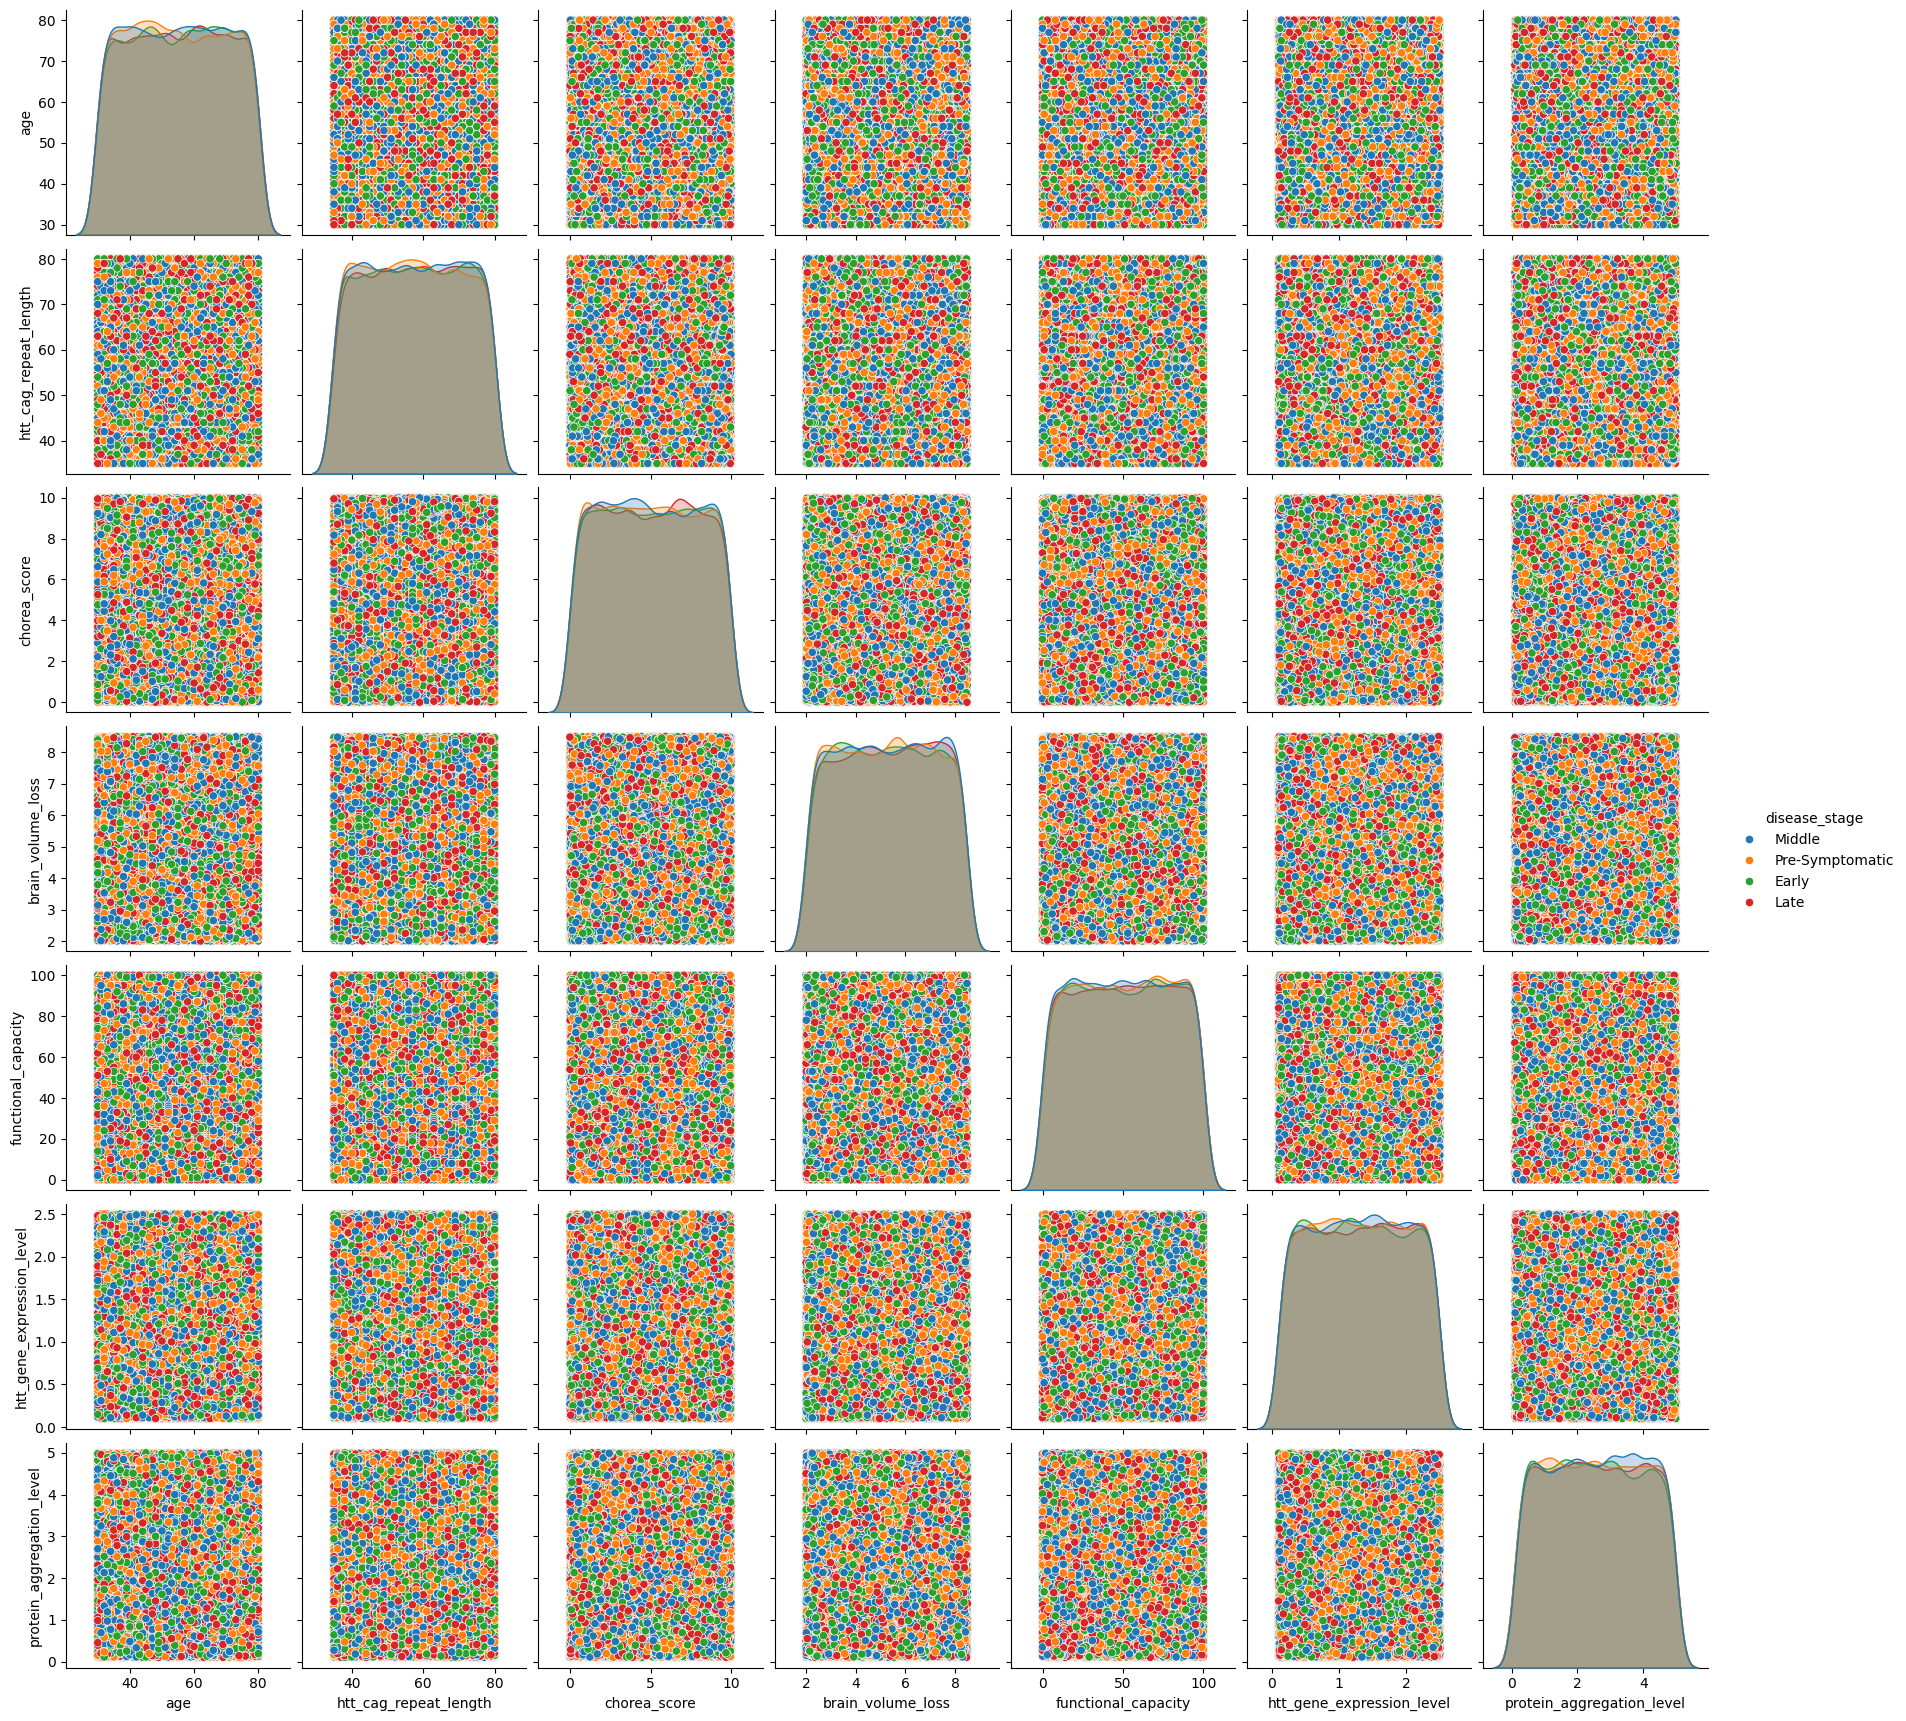

In [98]:
# Pairwise Relationship Analysis of Numerical Features by Disease Stage
sns.pairplot(df , vars = num_col , hue = 'disease_stage')
plt.show()

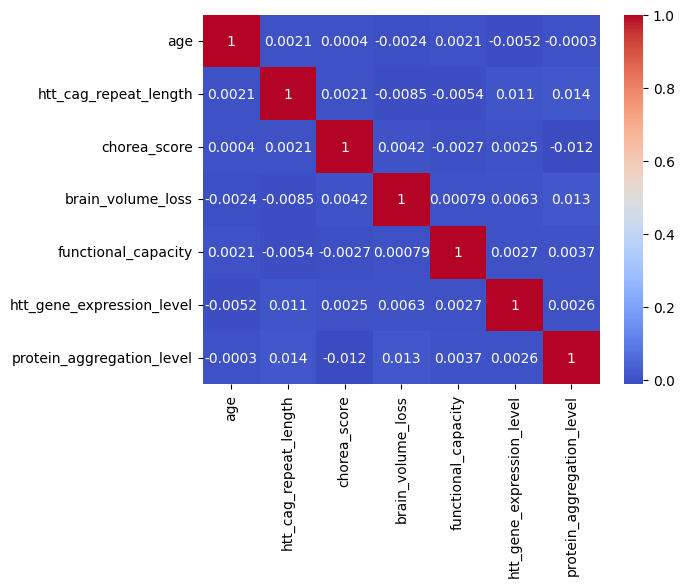

In [99]:
# For multicolinearity

num_features = df[num_col].select_dtypes(include = ['number'])
corr = num_features.corr()
sns.heatmap(corr , annot = True , cmap = 'coolwarm')
plt.show()

In [103]:
!pip install statsmodels

  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.3 MB 7.8 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 6.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.3 MB 5.8 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.3 MB 6.1 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.3 MB 6.2 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.3 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 11.0/11.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 6.5 MB/s eta 0:00:01
   -----------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
# VIF (Variance Inflation Factor) is used to detect multicollinearity among numerical independent features in a dataset.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[num_col].dropna()

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,age,1.000042
1,htt_cag_repeat_length,1.000446
2,chorea_score,1.000194
3,brain_volume_loss,1.000298
4,functional_capacity,1.000063
5,htt_gene_expression_level,1.000212
6,protein_aggregation_level,1.000545


Categorical × Categorical × Target

In [101]:
cat_col

Index(['patient_id', 'sex', 'family_history', 'motor_symptoms',
       'cognitive_decline', 'gene_mutation_type', 'random_protein_sequence',
       'random_gene_sequence', 'disease_stage', 'gene/factor',
       'chromosome_location', 'function', 'effect', 'category'],
      dtype='object')

In [105]:
# Disease Stage Distribution by Sex and Gene/Factor
pd.crosstab(
    [df['sex'], df['gene/factor']],
    df['disease_stage'],
    normalize='index'
)*100

disease_stage           Early       Late     Middle  Pre-Symptomatic
sex    gene/factor                                                  
Female HTT          25.461677  24.807975  25.494362        24.235986
       HTTSE        25.104184  25.070845  25.020837        24.804134
       MLH1         24.372642  24.421847  24.930294        26.275217
       MSH3         25.301404  24.492155  25.136251        25.070190
Male   HTT          24.566285  24.909984  25.368249        25.155483
       HTTSE        23.668933  25.642727  24.912921        25.775419
       MLH1         25.024486  24.698008  25.563173        24.714332
       MSH3         24.812531  24.145976  26.128979        24.912515

Numerical × Categorical × Target

In [ ]:
num_col

Index(['age', 'htt_cag_repeat_length', 'chorea_score', 'brain_volume_loss',
       'functional_capacity', 'htt_gene_expression_level',
       'protein_aggregation_level'],
      dtype='object')

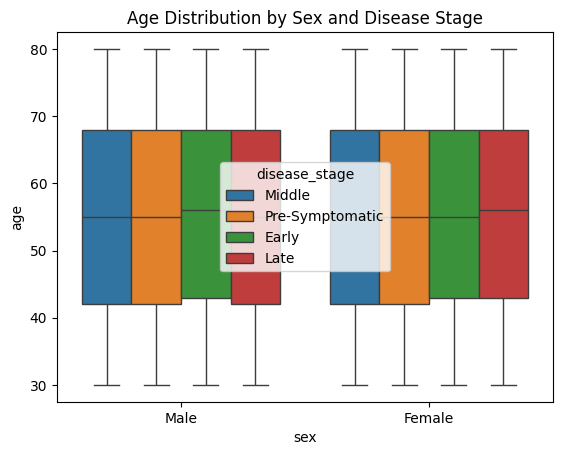

In [ ]:
sns.boxplot(
    data=df,
    x='sex',
    y='age',
    hue='disease_stage'
)

plt.title('Age Distribution by Sex and Disease Stage')
plt.show()

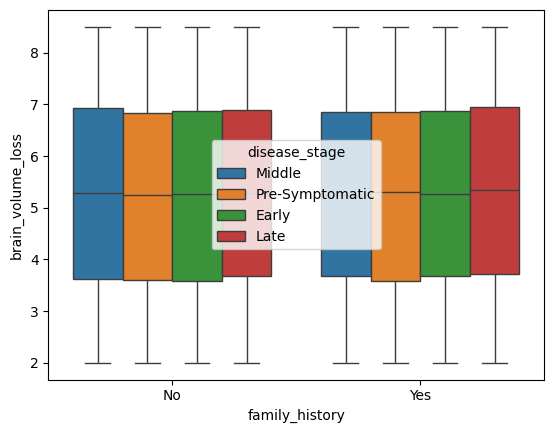

In [ ]:
sns.boxplot(data=df, x='family_history', y='brain_volume_loss', hue='disease_stage')
plt.show()

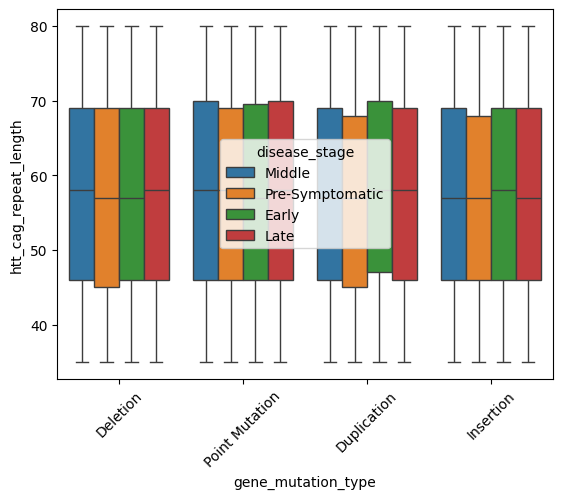

In [ ]:
sns.boxplot(data=df, x='gene_mutation_type', y='htt_cag_repeat_length', hue='disease_stage')
plt.xticks(rotation=45)
plt.show()

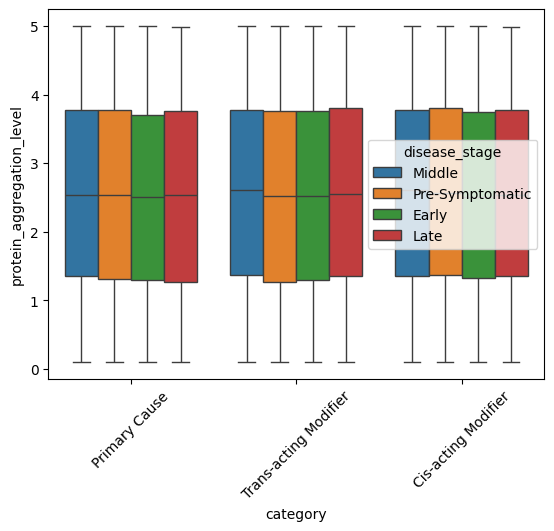

In [ ]:
sns.boxplot(data=df, x='category', y='protein_aggregation_level', hue='disease_stage')
plt.xticks(rotation=45)
plt.show()

**Observations Till EDA**

* The dataset contains 48,536 records.
* The target variable is `Disease_Stage`, which is a multiclass categorical variable.
* The dataset contains both numerical and categorical features.
* Missing values were checked across the dataset using null counts and percentages.
* There have a column named as `Cognitive_decline` which have null values of approximately **25%** of the total columns data. It is a categorical data and it is important for prediction.

* Since the column has meaningful ordinal categories such as Mild, Moderate, and Severe, it is not a good idea to drop it. Missing-value handling should be evaluated carefully and also didn't fill by mode. i am normally fill it by 'Unknown'.
* Duplicate records were checked.
* No duplicate values in the dataset .
* Outliers or wrong values were checked.
* No outliers in the numerical col and no wrong values in the categorical col.
* Data are Normally distributed.

* There have value merged columns like `Chromosome_Location` . i was normally split into Chromosome , Chromosome_Arm , Chromosome_Region.

* These should generally be treated as categorical features, rather than treating 16.3 or 14.1 as ordinary continuous numbers.

* Using alpha = 0.05
`Protein_Aggregation_Level` and `HTT_CAG_Repeat_Length` showed statistically significant association with the target.
The remaining numerical features did not show statistically significant association based on this test.


* Therefore, at the 5% significance level, these features did not show statistically significant association with Disease_Stage according to the Chi-square test.

* I found Patient_ID , Random_Gene_Sequence , Random_Protein_Sequence
with extremely high Chi-square scores.
These should not automatically be selected because of their high Chi-square scores.

* Patient_ID is an identifier and should be removed.
* Random_Gene_Sequence and Random_Protein_Sequence appear to be random/high-cardinality sequence features.

* Then go for categorical data encoding , for diff categorical data using diff encoding methods , for target col use `LabelEncoder()`.
* After it Performing Splitting by `train_test_split`.

take x and y

In [107]:
x = df.drop(columns = ['disease_stage'])
y = df['disease_stage']


Splitting

In [108]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size = 0.2 , random_state =42, stratify = y )

In [113]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(38828, 20)
(9708, 20)
(38828,)
(9708,)
